# Suite 2 — Micro-Level Spatial Downscaling Efficacy

**Goal:** did the CF + per-model calibration downscaling fix the catastrophic municipal bias (large negative for wind, positive for solar)?

Sources: `results/kwusterhausen/kw_multi_model_validation.parquet` (per-hour Königs Wusterhausen actuals + already-calibrated per-model predictions), `results/kwusterhausen/kw_validation_metrics.csv`, and `results/macro_cv_metrics.csv`.

In [1]:
import os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Anchor to repo root so relative data/results paths work whether the notebook
# is launched from notebooks/ or the project root.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.titleweight": "bold", "axes.grid": True, "grid.alpha": 0.3,
})
FIG = "results/figures"
os.makedirs(FIG, exist_ok=True)

def save(fig, name):
    p = os.path.join(FIG, name)
    fig.savefig(p)
    print("saved ->", p)
    return p

# Consistent model palette across every suite.
MODEL_ORDER = ["persistence", "climatology", "lightgbm", "xgboost", "ebm", "bilstm", "tft"]
PAL = dict(zip(MODEL_ORDER, sns.color_palette("colorblind", len(MODEL_ORDER))))
BASELINES = {"persistence", "climatology"}


In [2]:
kw = pd.read_parquet("results/kwusterhausen/kw_multi_model_validation.parquet")
kw.index = pd.to_datetime(kw.index, utc=True)
kwm = pd.read_csv("results/kwusterhausen/kw_validation_metrics.csv")
ACT = {"wind": "windkraft", "solar": "photovoltaik"}
# Derive the model list from what the validators actually wrote: TFT rows only
# exist after src.validation.tft_municipal_validator has run against the same
# parquet, and municipal_validator rewrites the file without them.
MODELS = {tech: [m for m in MODEL_ORDER if f"pred_{m}_{tech}" in kw.columns]
          for tech in ("wind", "solar")}
print(kw.shape, MODELS)
missing = set(MODEL_ORDER) - BASELINES - set(MODELS["wind"]) - set(MODELS["solar"])
if missing:
    print("no municipal predictions for:", sorted(missing),
          "-> rerun the matching validator to include them")
kw.head(2)

(1451, 18) {'wind': ['lightgbm', 'xgboost', 'ebm', 'bilstm'], 'solar': ['lightgbm', 'xgboost', 'ebm', 'bilstm']}
no municipal predictions for: ['tft'] -> rerun the matching validator to include them


,photovoltaik,windkraft,pred_lightgbm_wind,pred_lightgbm_wind_lower,pred_lightgbm_wind_upper,pred_lightgbm_wind_lower_conformal,pred_lightgbm_wind_upper_conformal,pred_xgboost_wind,pred_ebm_wind,pred_bilstm_wind,pred_lightgbm_solar,pred_lightgbm_solar_lower,pred_lightgbm_solar_upper,pred_lightgbm_solar_lower_conformal,pred_lightgbm_solar_upper_conformal,pred_xgboost_solar,pred_ebm_solar,pred_bilstm_solar
2026-05-28 13:00:00+00:00,2310.840468,238.119917,936.915630,748.817372,1175.417751,0.0,2033.086612,906.898043,1025.443571,NaN,2505.434109,2198.666212,2712.304815,2141.409849,2769.561178,2537.994194,2385.507674,NaN
2026-05-28 14:00:00+00:00,2132.708920,447.309750,920.216816,791.134563,1140.114699,0.0,1997.783560,920.872210,1102.564672,NaN,2157.921518,2061.283328,2444.357304,2004.026965,2501.613667,2196.019180,2141.589651,NaN


## 2a — Municipal residual distributions (pred − actual)

A downscaler that works is centred on zero. The pre-rework failure was a large-magnitude offset.

saved -> results/figures/s2_residual_kde.png


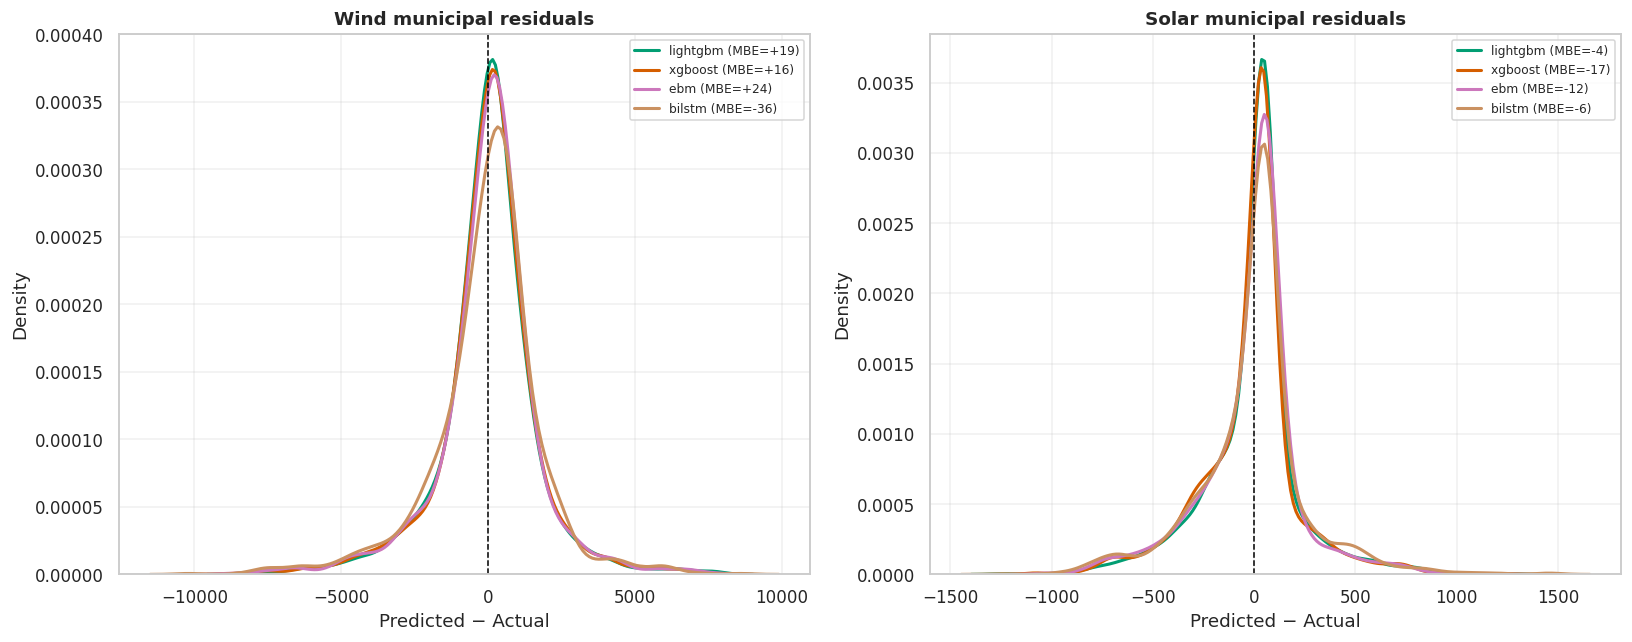

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, tech in zip(axes, ["wind","solar"]):
    act = kw[ACT[tech]]
    for model in MODELS[tech]:
        col = f"pred_{model}_{tech}"
        resid = (kw[col] - act).dropna()
        sns.kdeplot(resid, ax=ax, label=f"{model} (MBE={resid.mean():+.0f})",
                    color=PAL[model], lw=2)
    ax.axvline(0, color="black", ls="--", lw=1)
    ax.set_title(f"{tech.title()} municipal residuals"); ax.set_xlabel("Predicted − Actual")
    ax.legend(fontsize=8)
fig.tight_layout(); save(fig, "s2_residual_kde.png"); plt.show()

## 2b — Hour-of-day Mean Bias Error heatmaps

Which times of day (proxy for weather/irradiance regime) still break the downscaler.

saved -> results/figures/s2_mbe_hour_heatmap.png


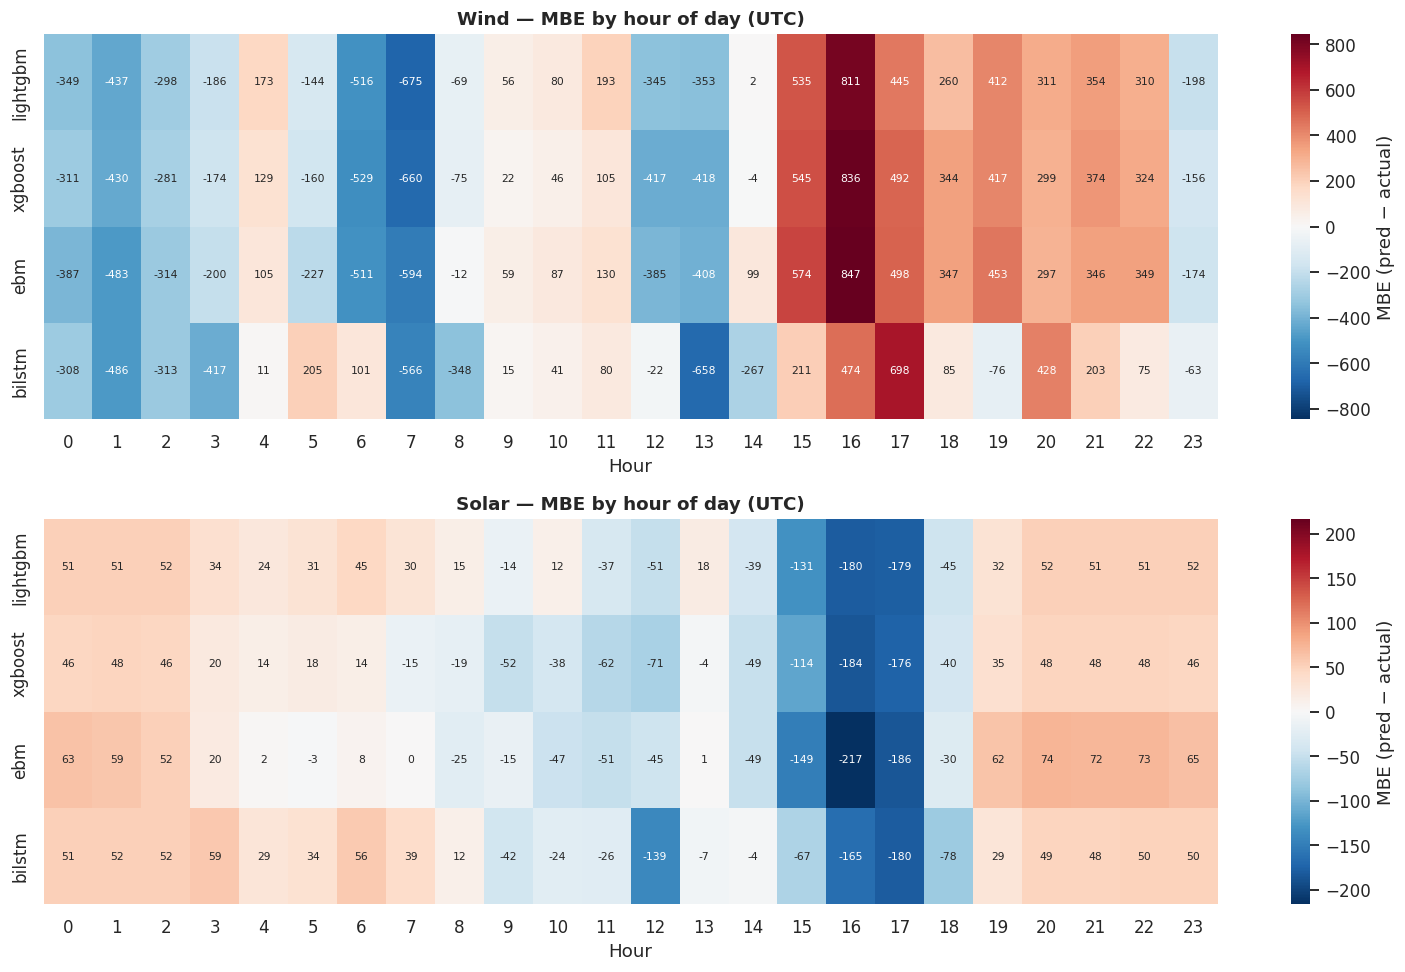

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
for ax, tech in zip(axes, ["wind","solar"]):
    act = kw[ACT[tech]]
    mat = {}
    for model in MODELS[tech]:
        resid = kw[f"pred_{model}_{tech}"] - act
        mat[model] = resid.groupby(resid.index.hour).mean()
    M = pd.DataFrame(mat).T.reindex(index=MODELS[tech])
    vmax = np.nanmax(np.abs(M.values))
    sns.heatmap(M, ax=ax, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                cbar_kws={"label": "MBE (pred − actual)"}, annot=True, fmt=".0f", annot_kws={"size":7})
    ax.set_title(f"{tech.title()} — MBE by hour of day (UTC)"); ax.set_xlabel("Hour"); ax.set_ylabel("")
fig.tight_layout(); save(fig, "s2_mbe_hour_heatmap.png"); plt.show()

## 2c — Scale gap: macro (state) vs micro (municipal) nMAE

saved -> results/figures/s2_macro_vs_micro_nmae.png


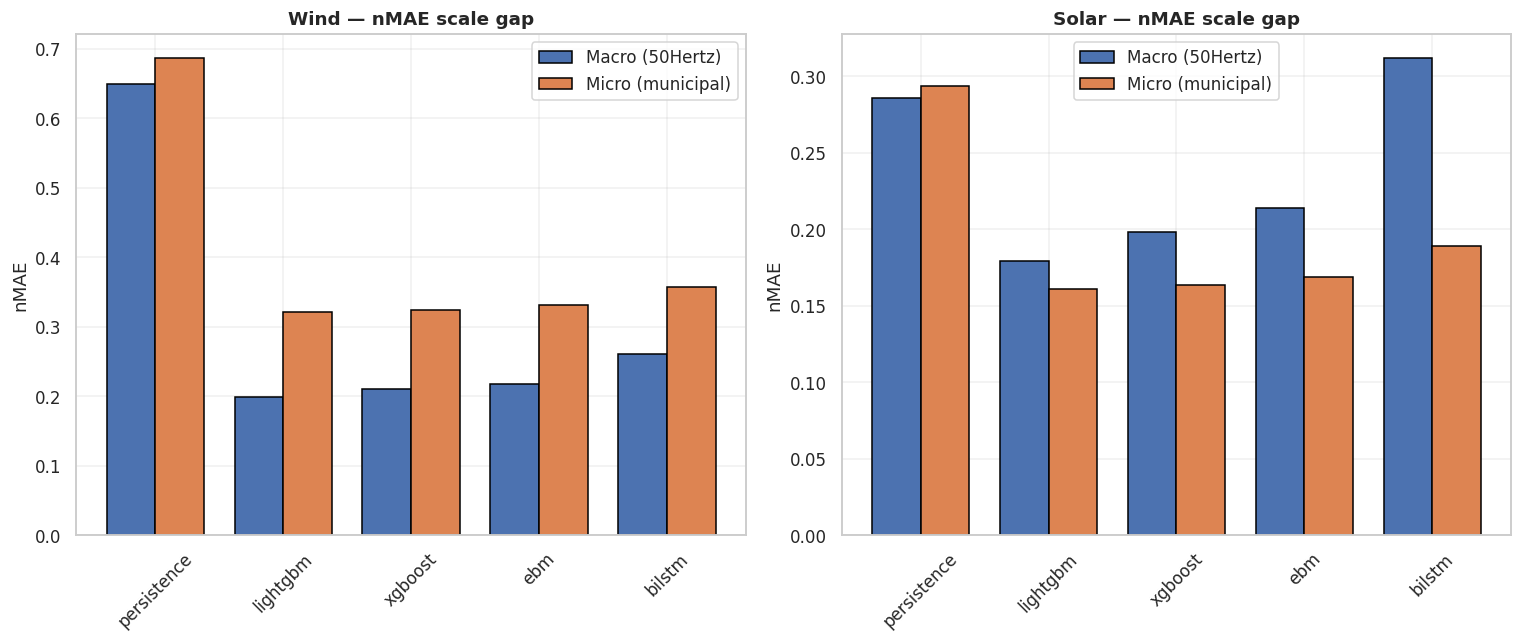

,technology,model,macro_nmae,micro_nmae
3,solar,persistence,0.286020,0.293711
2,solar,lightgbm,0.179330,0.161056
4,solar,xgboost,0.198087,0.163885
1,solar,ebm,0.213673,0.169176
0,solar,bilstm,0.312279,0.189064
8,wind,persistence,0.648887,0.687107
7,wind,lightgbm,0.198849,0.321666
9,wind,xgboost,0.211046,0.324736
6,wind,ebm,0.218054,0.331274
5,wind,bilstm,0.260569,0.357020


In [5]:
# Macro nMAE at MW scale, averaged over folds; micro nMAE straight from the
# municipal validation metrics.
macro = pd.read_csv("results/macro_cv_metrics.csv")
macro_mw = macro[macro.scale == "mw"].groupby(["technology","model"])["nmae"].mean().reset_index()
macro_mw = macro_mw.rename(columns={"nmae":"macro_nmae"})
micro = kwm.rename(columns={"nmae":"micro_nmae"})[["technology","model","micro_nmae"]]
comp = macro_mw.merge(micro, on=["technology","model"], how="inner")
comp["model"] = pd.Categorical(comp["model"], MODEL_ORDER, ordered=True)
comp = comp.sort_values(["technology","model"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, tech in zip(axes, ["wind","solar"]):
    sub = comp[comp.technology == tech]
    x = np.arange(len(sub)); w = 0.38
    ax.bar(x - w/2, sub["macro_nmae"], w, label="Macro (50Hertz)", color="#4c72b0", edgecolor="black")
    ax.bar(x + w/2, sub["micro_nmae"], w, label="Micro (municipal)", color="#dd8452", edgecolor="black")
    ax.set_xticks(x); ax.set_xticklabels(sub["model"].astype(str), rotation=45)
    ax.set_title(f"{tech.title()} — nMAE scale gap"); ax.set_ylabel("nMAE"); ax.legend()
fig.tight_layout(); save(fig, "s2_macro_vs_micro_nmae.png"); plt.show(); comp

## 2d — Leave-one-municipality-out: does the affine calibration transfer?

§6.5 validates each town with an affine contract fitted on *that town's own*
telemetry. The 16 unvalidated Brandenburg districts have no telemetry at all, so
the operationally honest question is whether a `(scale, offset)` fitted at one
municipality survives being moved to another. `src.validation.lomo_transfer` fits
at one town and applies it verbatim at the other, in both directions.

Three variants, all scored on the same held-out window:

| variant | meaning |
|---|---|
| `oracle` | the target's own fitted calibration — the upper bound, i.e. the §6.5 number |
| `transferred` | the donor town's frozen calibration, applied verbatim |
| `uncalibrated` | `scale = 1, offset = 0` — raw CF × local nameplate |

**The right-hand panel is the argument.** An affine map with positive slope is a
monotone linear rescaling, so it cannot change Pearson r — correlation is
*identical* across all three variants by construction (asserted in the module's
self-check). Whatever transfer breaks, it is magnitude, never shape. That is the
empirical backing for the §7.4 claim that the wind divergence is capacity
*accounting* and not a failure of forecast skill.

saved -> results/figures/s2_lomo_transfer.png


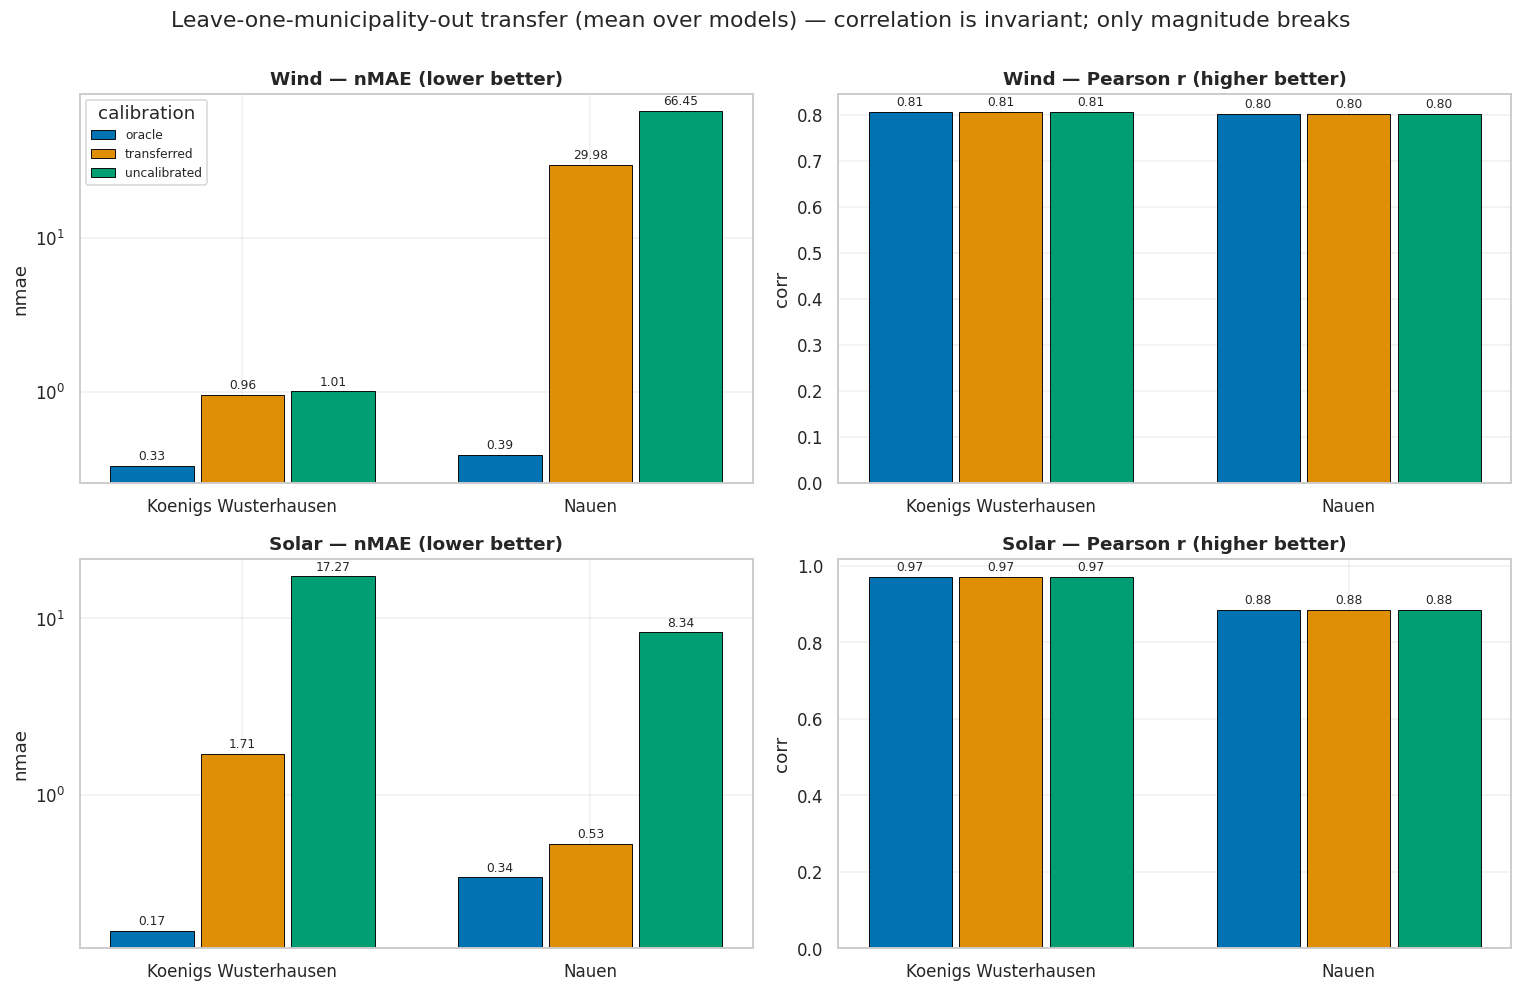

Donor scale / target's own scale (1.0 = perfect transfer):


model                            bilstm     ebm  lightgbm  xgboost
technology target                                                 
solar      koenigs_wusterhausen   1.828   1.867     1.850    1.871
           nauen                  0.547   0.536     0.541    0.534
wind       koenigs_wusterhausen   0.034   0.034     0.033    0.033
           nauen                 29.687  29.552    29.931   30.043

In [6]:
lomo = pd.read_csv("results/lomo_transfer.csv")
VAR_ORDER = ["oracle", "transferred", "uncalibrated"]
VPAL = dict(zip(VAR_ORDER, sns.color_palette("colorblind", 10)[:3]))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for r, tech in enumerate(["wind", "solar"]):
    sub = lomo[lomo["technology"] == tech]
    for c, (metric, label, logy) in enumerate(
            [("nmae", "nMAE (lower better)", True), ("corr", "Pearson r (higher better)", False)]):
        ax = axes[r, c]
        agg = (sub.groupby(["target", "variant"])[metric].mean()
                  .reindex(pd.MultiIndex.from_product(
                      [sorted(sub["target"].unique()), VAR_ORDER], names=["target", "variant"]))
                  .reset_index())
        w, targets = 0.26, sorted(sub["target"].unique())
        for k, v in enumerate(VAR_ORDER):
            vals = agg[agg["variant"] == v][metric].to_numpy()
            x = np.arange(len(targets)) + (k - 1) * w
            b = ax.bar(x, vals, w * 0.92, color=VPAL[v], edgecolor="black",
                       linewidth=0.6, label=v)
            ax.bar_label(b, fmt="%.2f", fontsize=8, padding=2)
        if logy:
            ax.set_yscale("log")   # oracle ~0.3 vs uncalibrated ~68 needs a log axis
        ax.set_xticks(np.arange(len(targets)))
        ax.set_xticklabels([t.replace("_", " ").title() for t in targets])
        ax.set_title(f"{tech.title()} — {label}")
        ax.set_ylabel(metric)
        if r == 0 and c == 0:
            ax.legend(title="calibration", fontsize=8)
fig.suptitle("Leave-one-municipality-out transfer (mean over models) — "
             "correlation is invariant; only magnitude breaks", y=1.00)
fig.tight_layout(); save(fig, "s2_lomo_transfer.png"); plt.show()

# The scale ratio is the accounting story in one number: how far the donor's
# fitted scale sits from the one the target actually needs.
piv = lomo[lomo["variant"] == "transferred"].pivot_table(
    index=["technology", "target"], columns="model", values="scale_ratio")
print("Donor scale / target's own scale (1.0 = perfect transfer):")
piv.round(3)